# 240501 Salicylate-Hypochlorite Ammonia Assay(Ammonium-N)
- Date: 5/13/24, experiment and measurement of 240501
- Analysis: Kiseok Lee
- Motivation: ammonia time series dynamics of soils with 3 different pH levels.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import numpy as np
import ammonia as am
import bmgdata as bd
import glob
import denitfit as dn
import pickle
import matplotlib.pyplot as plt
import os

# figure size and font size
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (20, 12),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Standard curves of Salicylate-Hypochlorite Ammonia Assay (Using bubble removal using well scan)

## 1.1. Standard curves on 240501 (10ul sampling)
standard

data/20250304_standards_metadata.csv
None
data/20250304_NH4_STD_chl+_650.CSV
data/20250304_NH4_STD_chl+_900.CSV
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []
A01    2.16325
A02    2.32390
A03    2.32530
A04    2.24335
B01    1.21245
B02    1.29725
B03    1.33760
B04    1.22355
C01    0.72475
C02    0.76290
C03    0.78620
C04    0.70650
D01    0.45885
D02    0.50020
D03    0.50320
D04    0.47380
E01    0.31895
E02    0.35215
E03    0.35040
E04    0.33590
F01    0.25965
F02    0.27390
F03    0.27775
F04    0.26125
G01    0.22695
G02    0.23915
G03    0.23775
G04    0.22655
H01    0.19370
H02    0.19970
H03    0.19855
H04    0.19200
Name: 650, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []
A01    2.16325
A02    2.32390
A03    2.32530
A04    2.24335
B01    1.21245
B02    1.29725
B03    1.33760
B04    1.22355
C01    0.72475
C02    0.76290


/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  #data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour

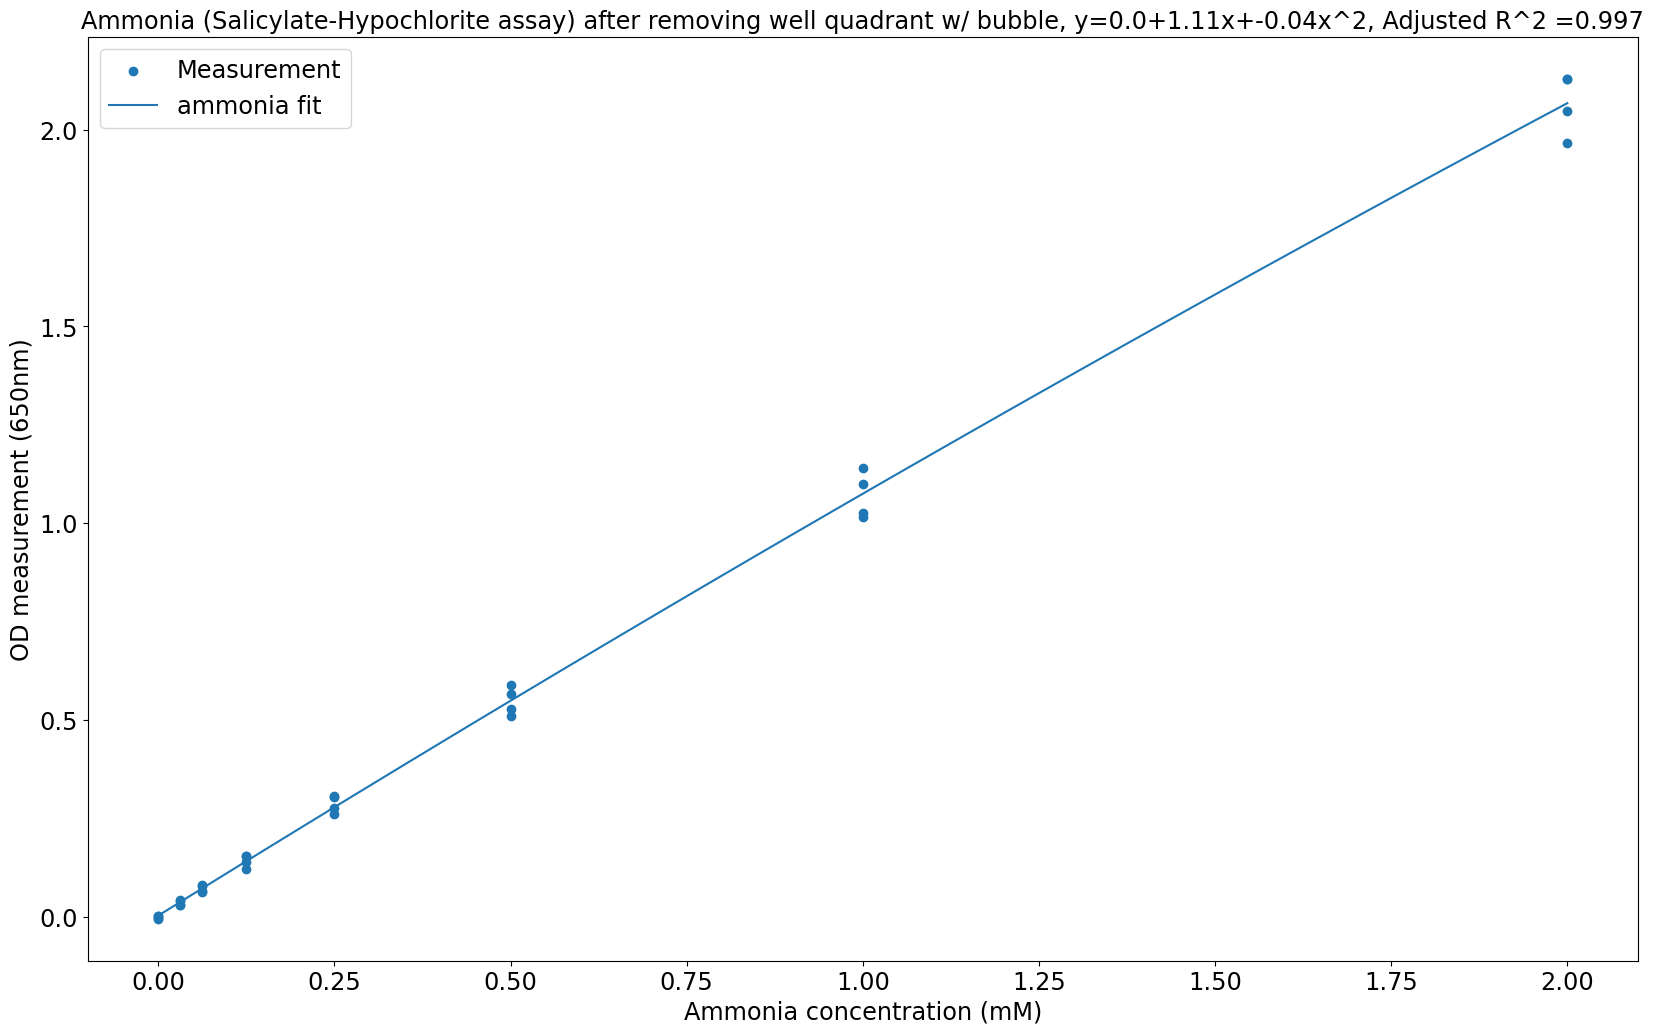

In [8]:
date = '20250304'
#fit Ammonia assay model using standard curves
std_meta_fn = f"data/{date}_standards_metadata.csv" # since 12C mg/ml and 16 C mg/ml is too high(recognize as bubbles). I'll eliminate those rows.
print(std_meta_fn)
#std_am_fn = None
#std_am_fn = glob.glob("./240501_Ammonia/*KL_Ammonia_no_scan*standard*")[0]
std_am_fn = None
print(std_am_fn)
std_am_absorb_fn = glob.glob(f"data/{date}_NH4_STD*650*")[0] # I included the standards in plate6 (last plate)
print(std_am_absorb_fn)
std_am_900_fn = glob.glob(f"data/{date}_NH4_STD*900*")[0]
print(std_am_900_fn)

# plot first
am.plot_ammonia_fit_rm_bubble(meta_fn = std_meta_fn, wavelength="650", data_fn = None, data_absorb_fn = std_am_absorb_fn, data_900_fn = std_am_900_fn)
plt.savefig(f'plots/{date}_salicylate-_standard_curve_10ul_with_bubble_removal.png')

# fit
fit_list = am.fit_ammonia(meta_fn = std_meta_fn, wavelength="650", data_fn = std_am_fn, data_absorb_fn = std_am_absorb_fn, data_900_fn = std_am_900_fn)
[[ammonia_blank], fit, b_fit] = fit_list 

print("fit: ", fit)
print("b_fit: ", b_fit, "\n")
# here I only have well scan data, so fit = b_fit

## 3.1. Soil7 and Soil10 Measuring ammonia for multiple soils

In [ ]:
## generate all sample names
#l_soil = ["AW_plate1_2", "Starke3","Oxbow3","Washington2"]
l_soil = ["Soil7"]
l_timepoint = ['T' + str(i) for i in range(0,9) ]

Note: you may need to restart the kernel to use updated packages.
Soil7_T0
data/20250304_samples_metadata.csv
None
data/20250304_NH4_chl+_tp3_650.CSV
data/20250304_NH4_chl+_tp3_900.CSV
Check wellscan for outlier removal in Ammonia
returns true for elements more than 1.5 interquartile ranges above the upper quartile


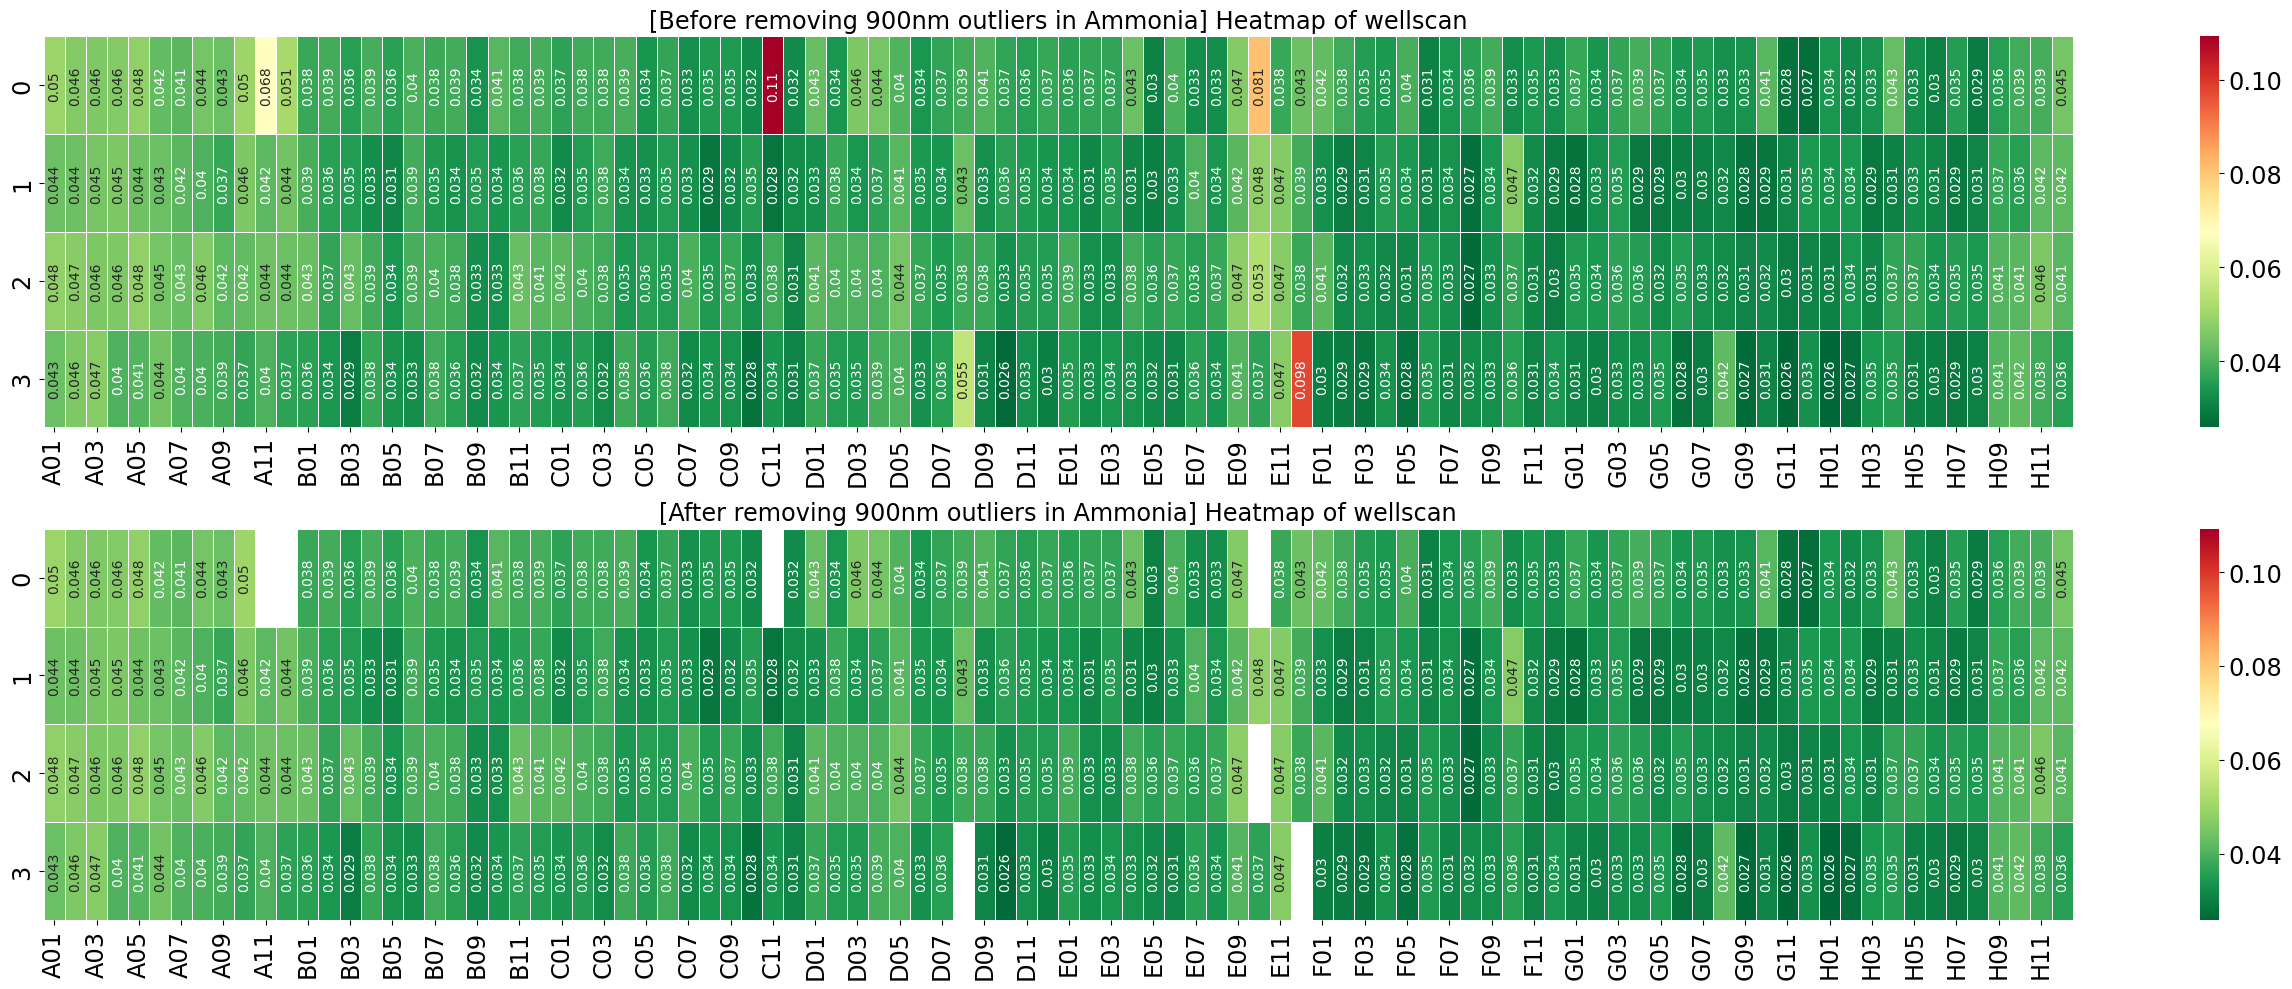

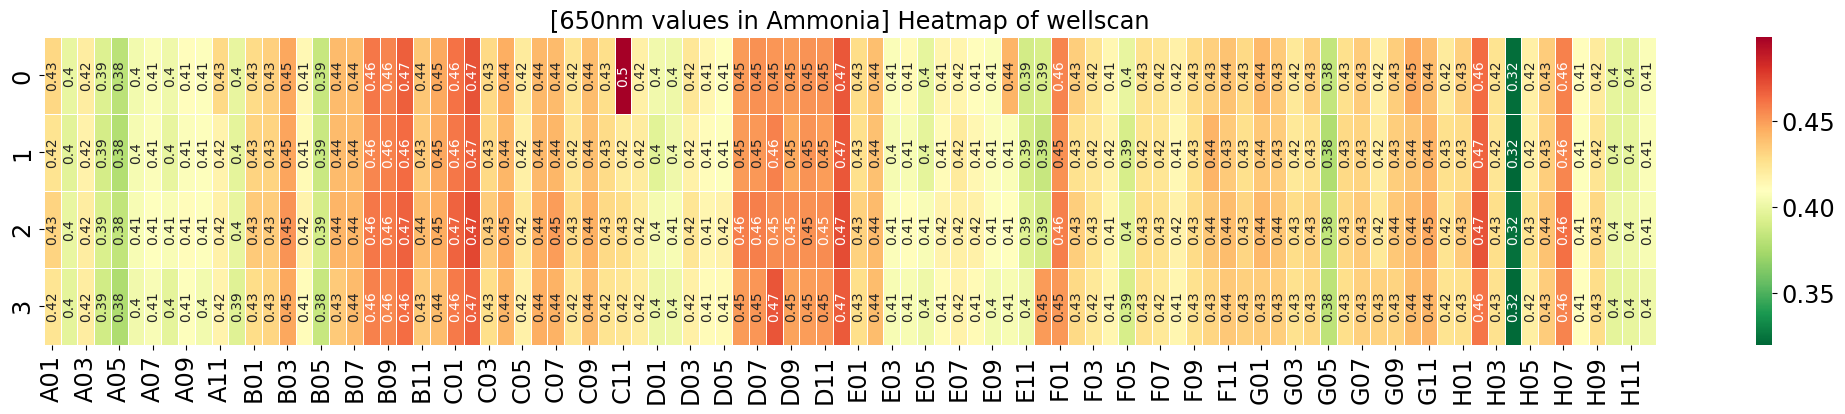

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

--------------------------------------------------------------------------------------------------------------
Soil7_T1
data/20250304_samples_metadata.csv
None
data/20250304_NH4_chl+_tp3_650.CSV
data/20250304_NH4_chl+_tp3_900.CSV
Check wellscan for outlier removal in Ammonia
returns true for elements more than 1.5 interquartile ranges above the upper quartile


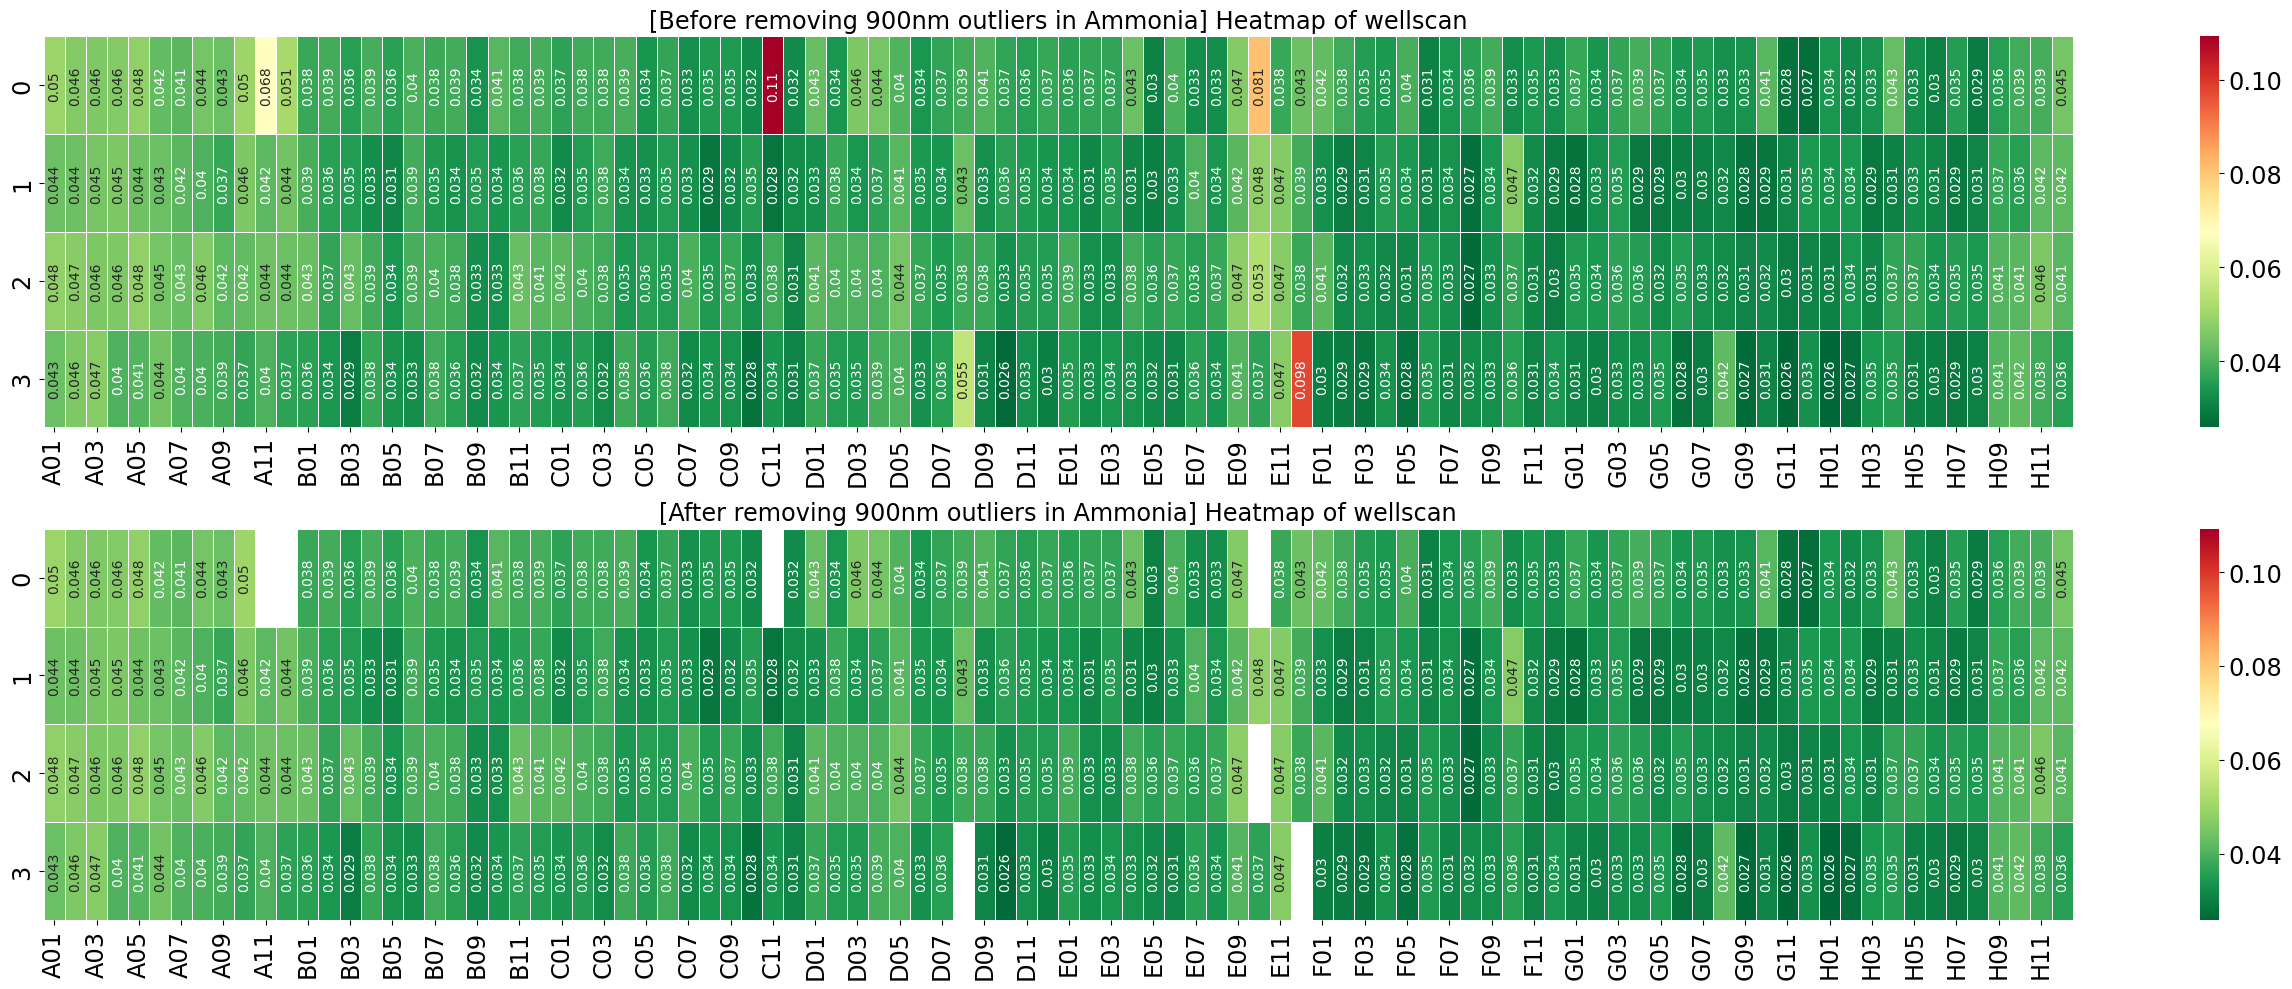

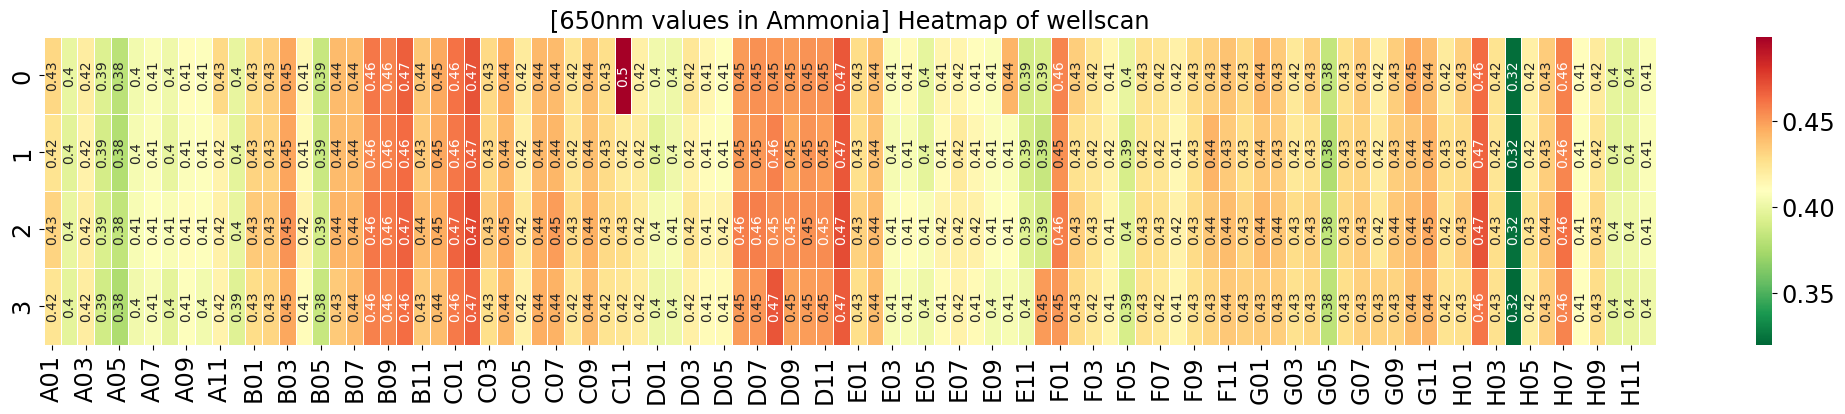

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

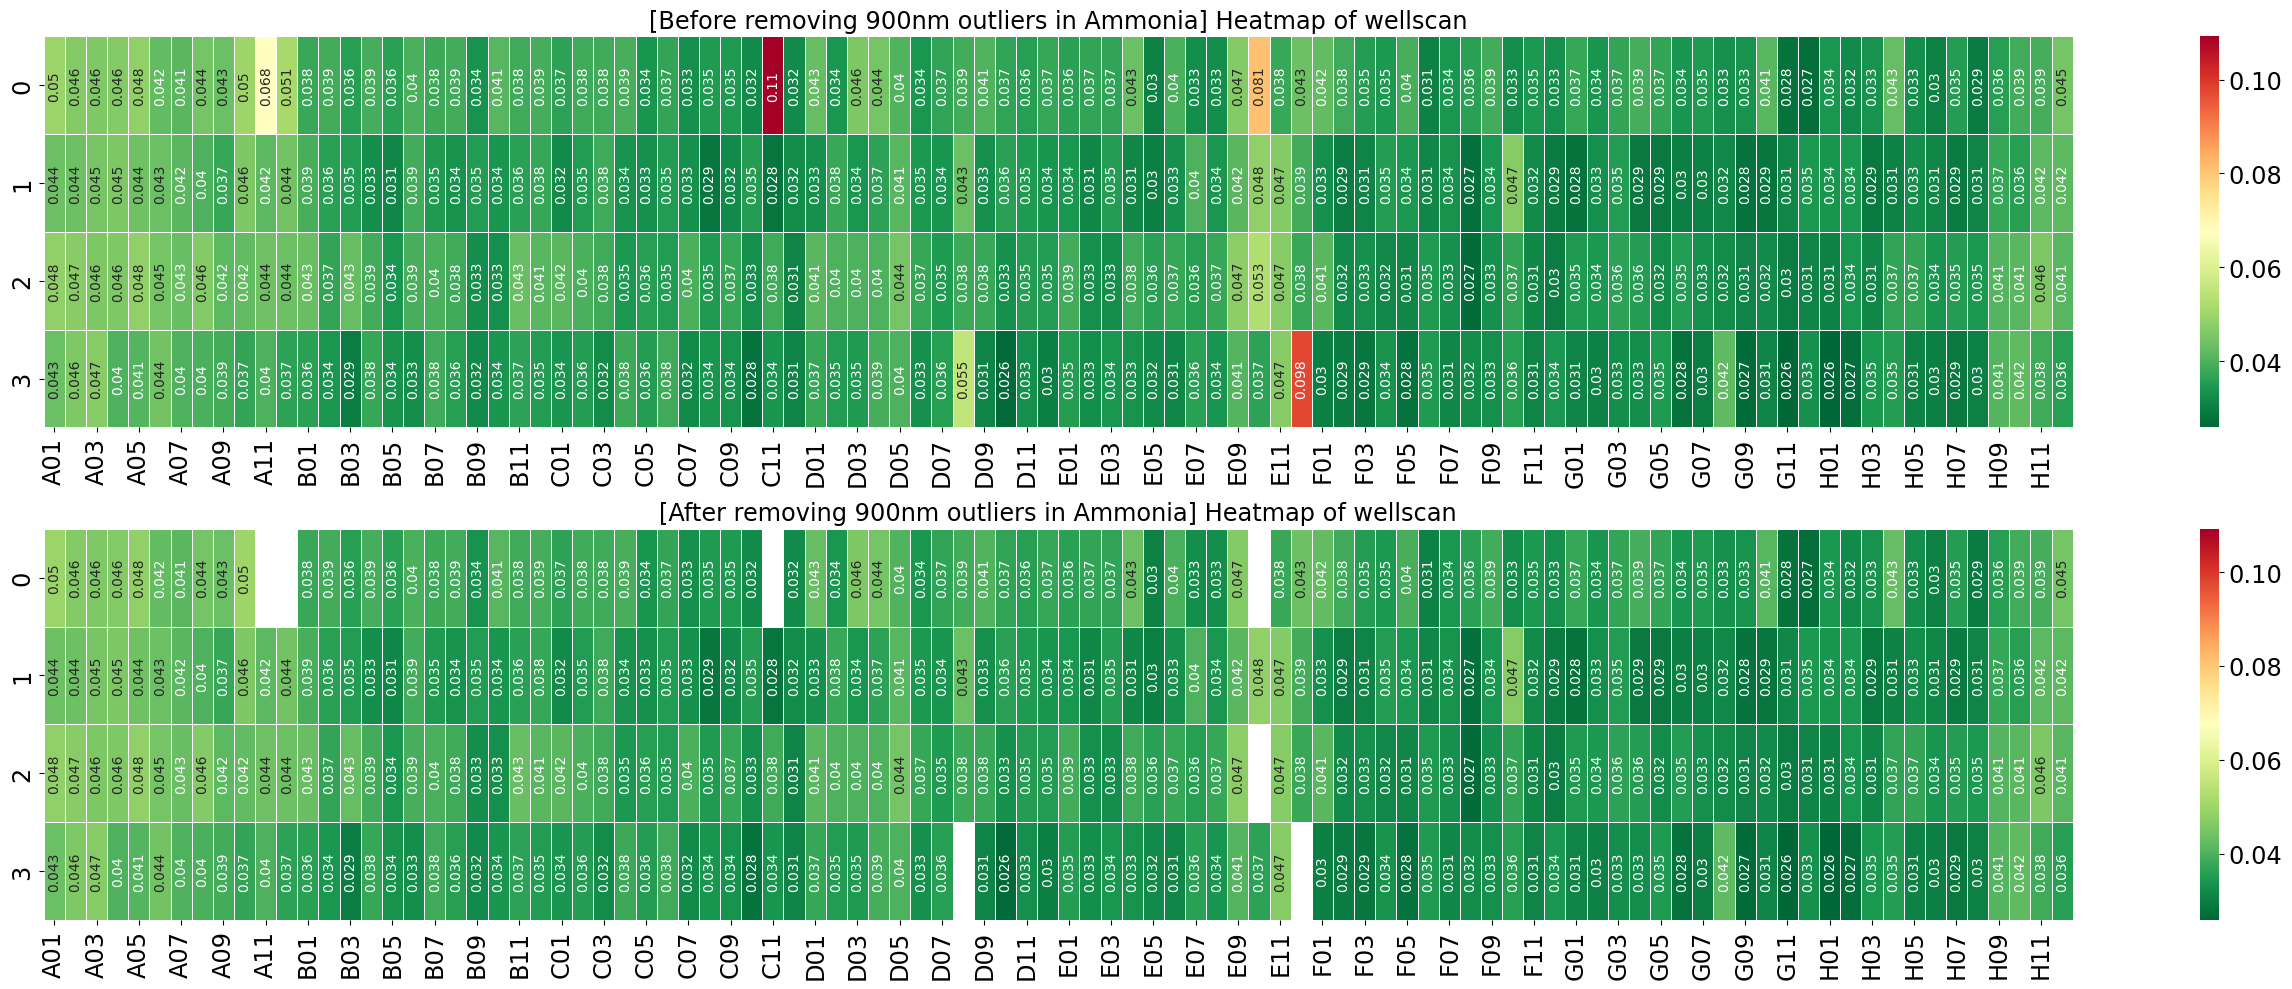

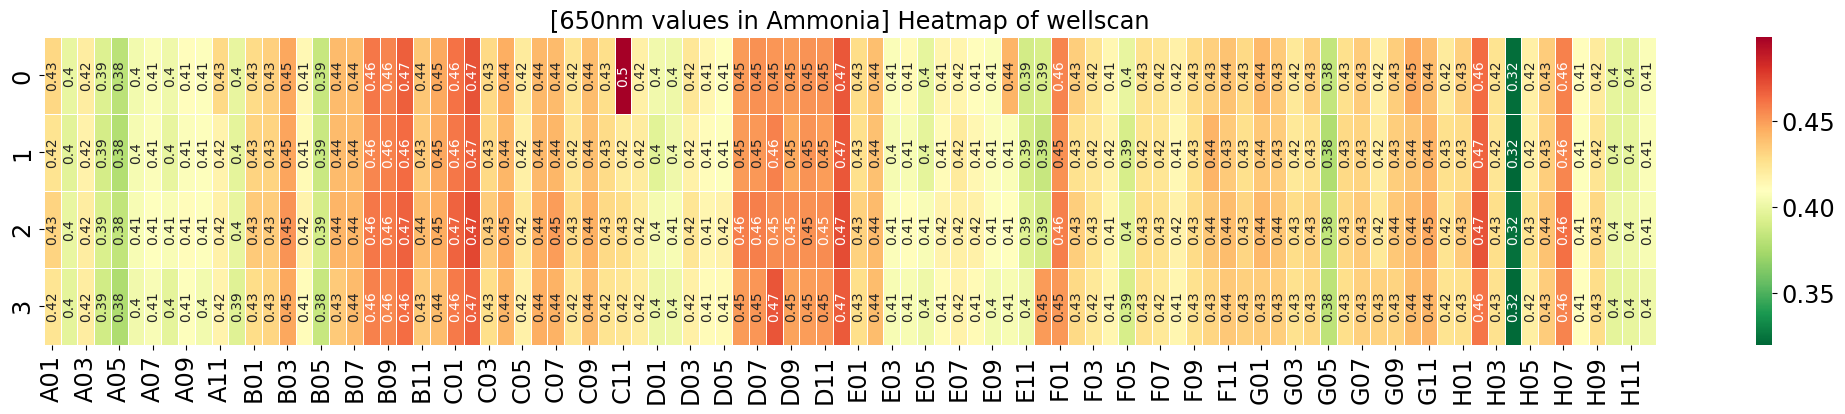

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

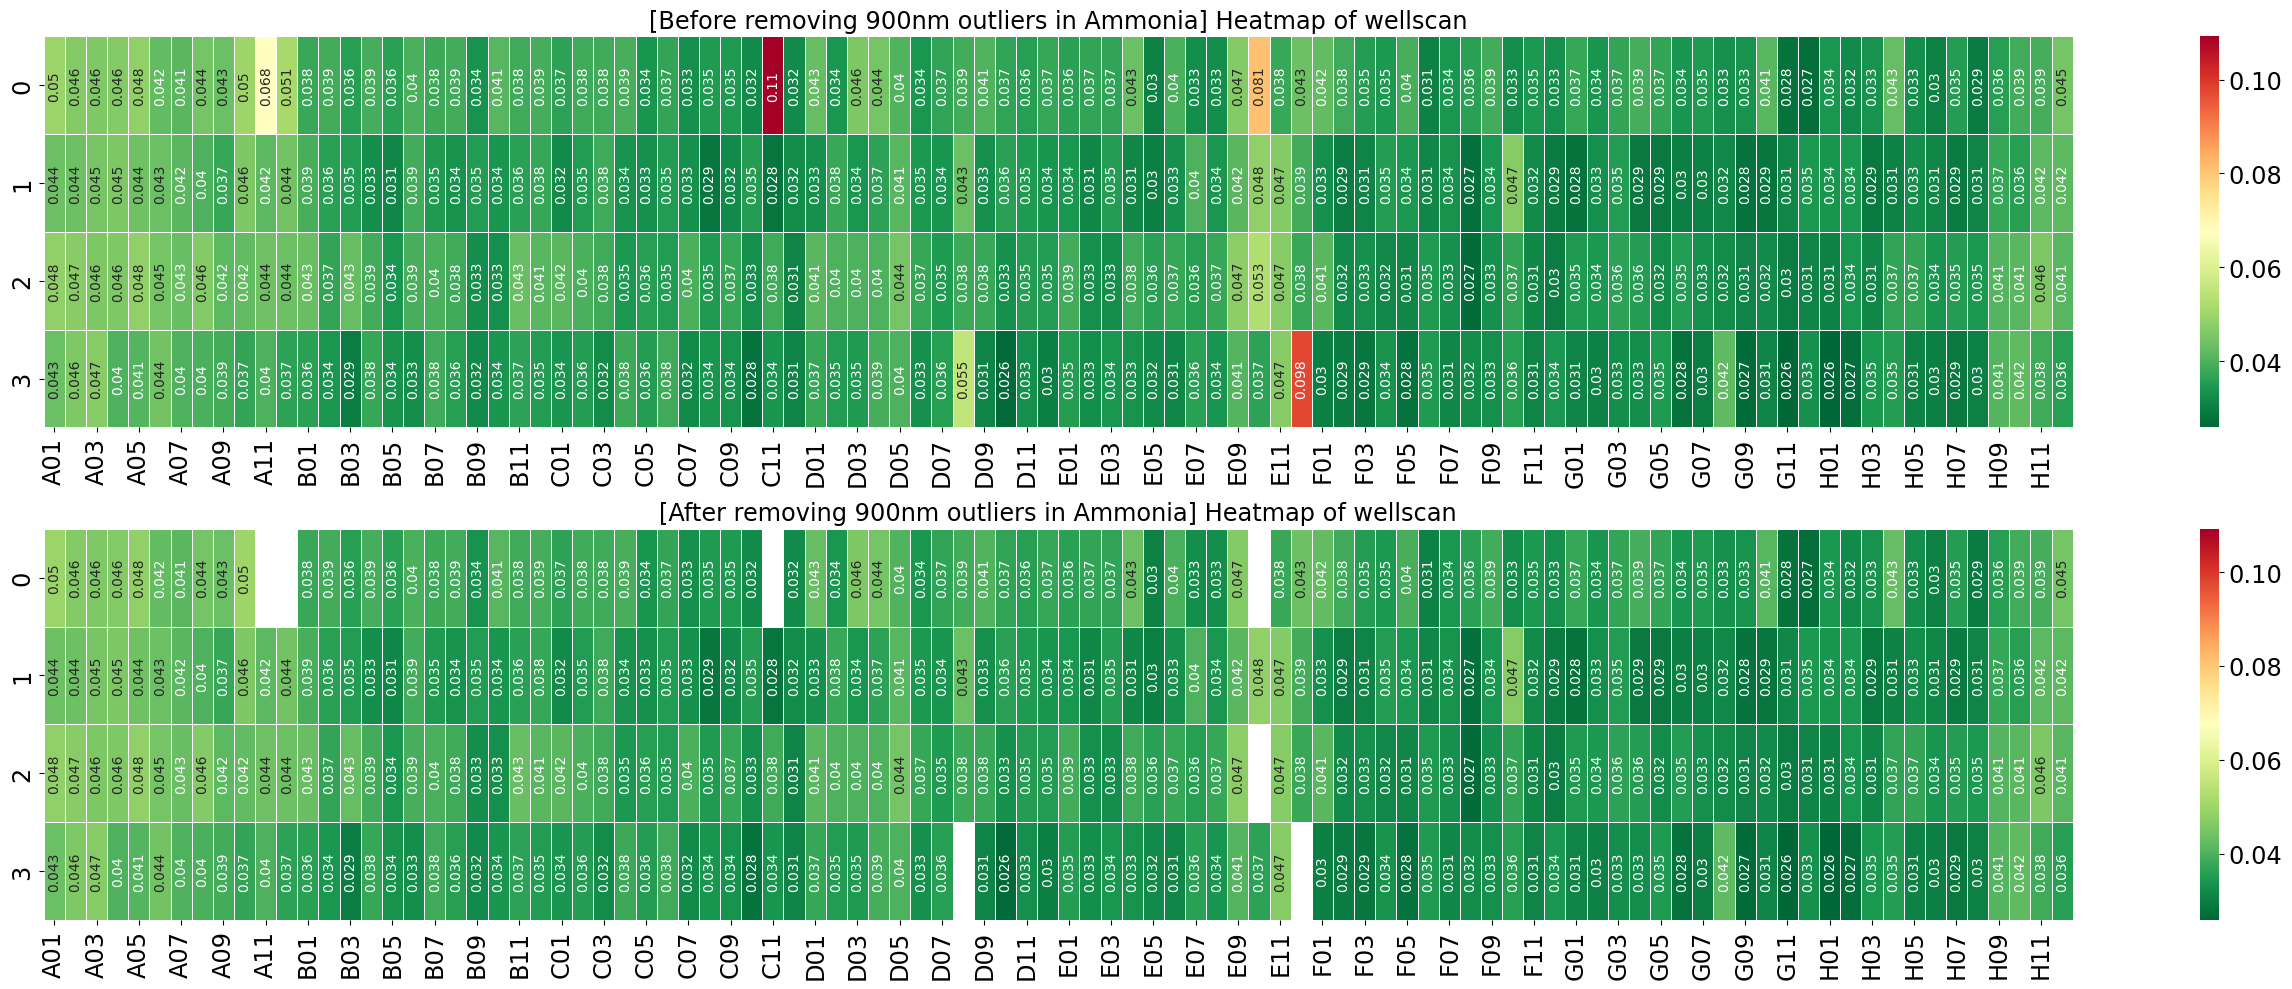

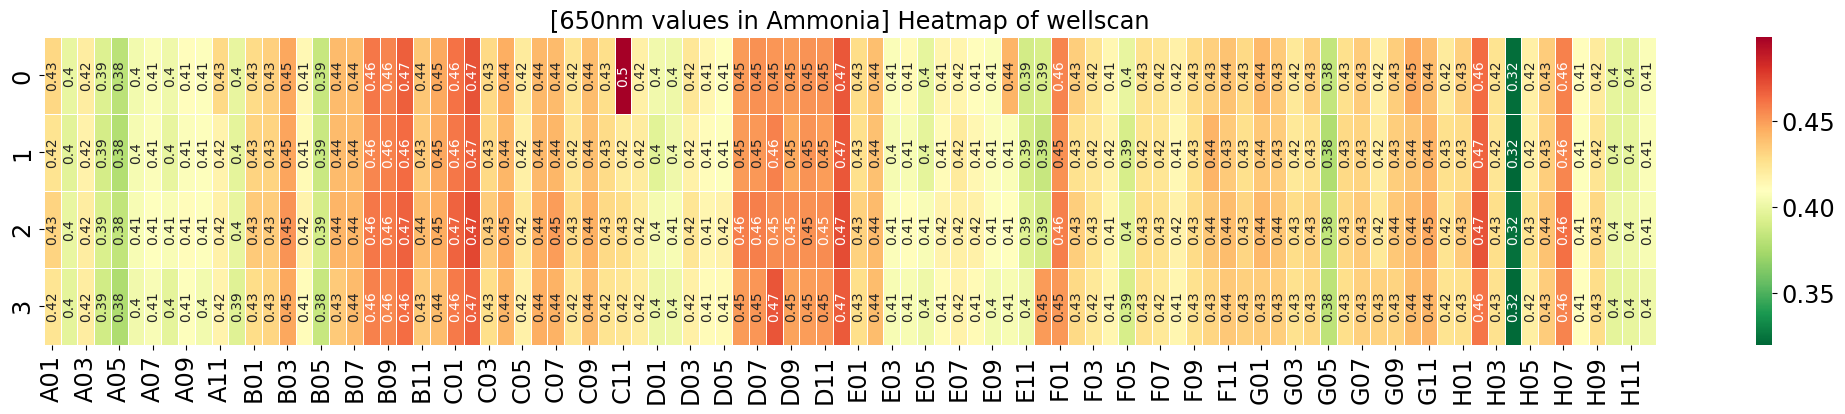

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

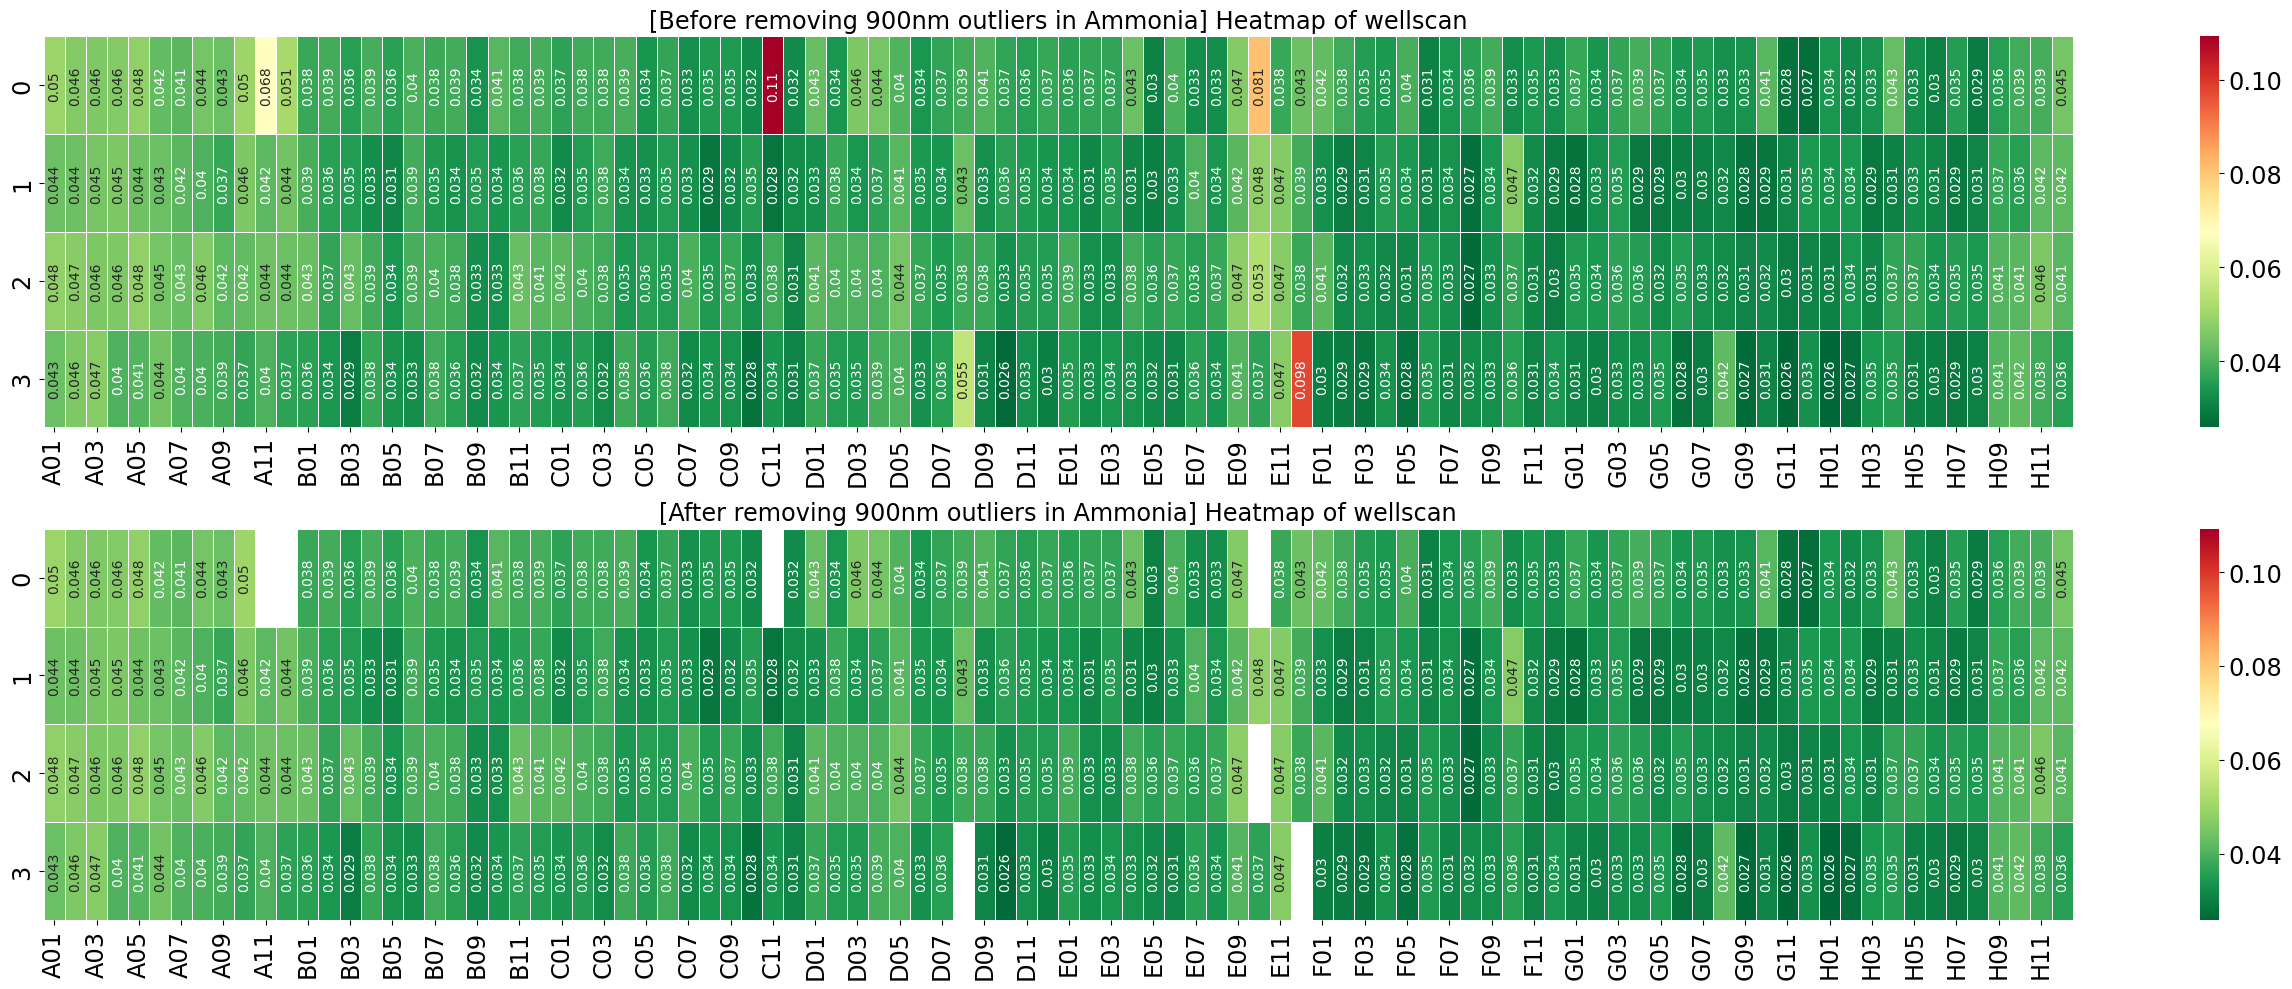

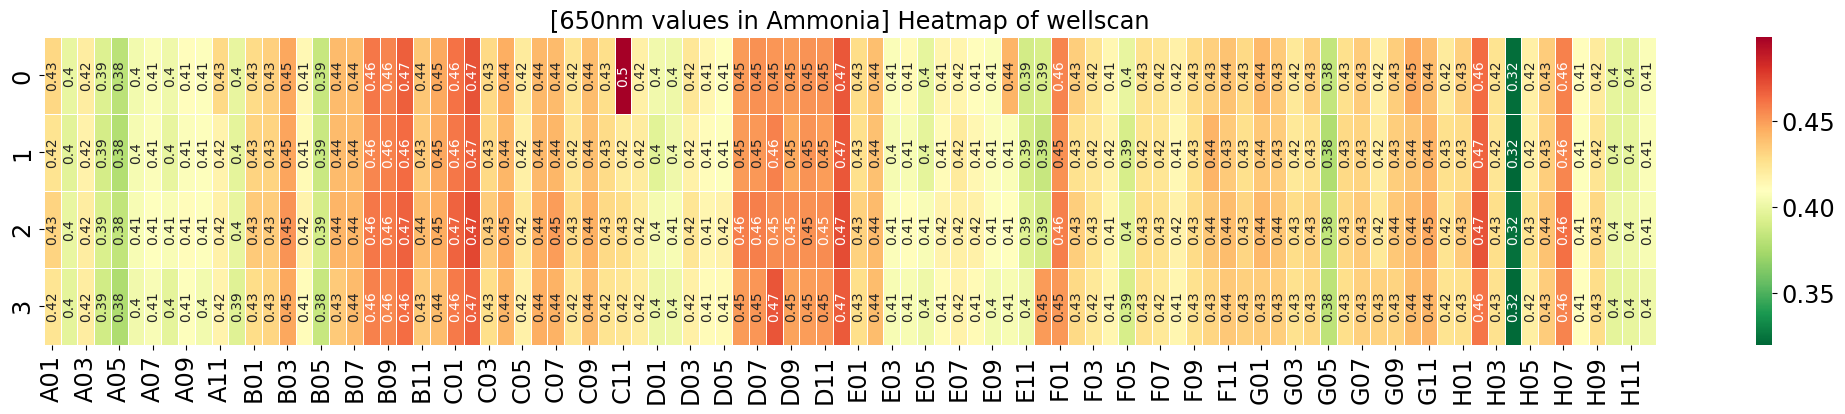

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

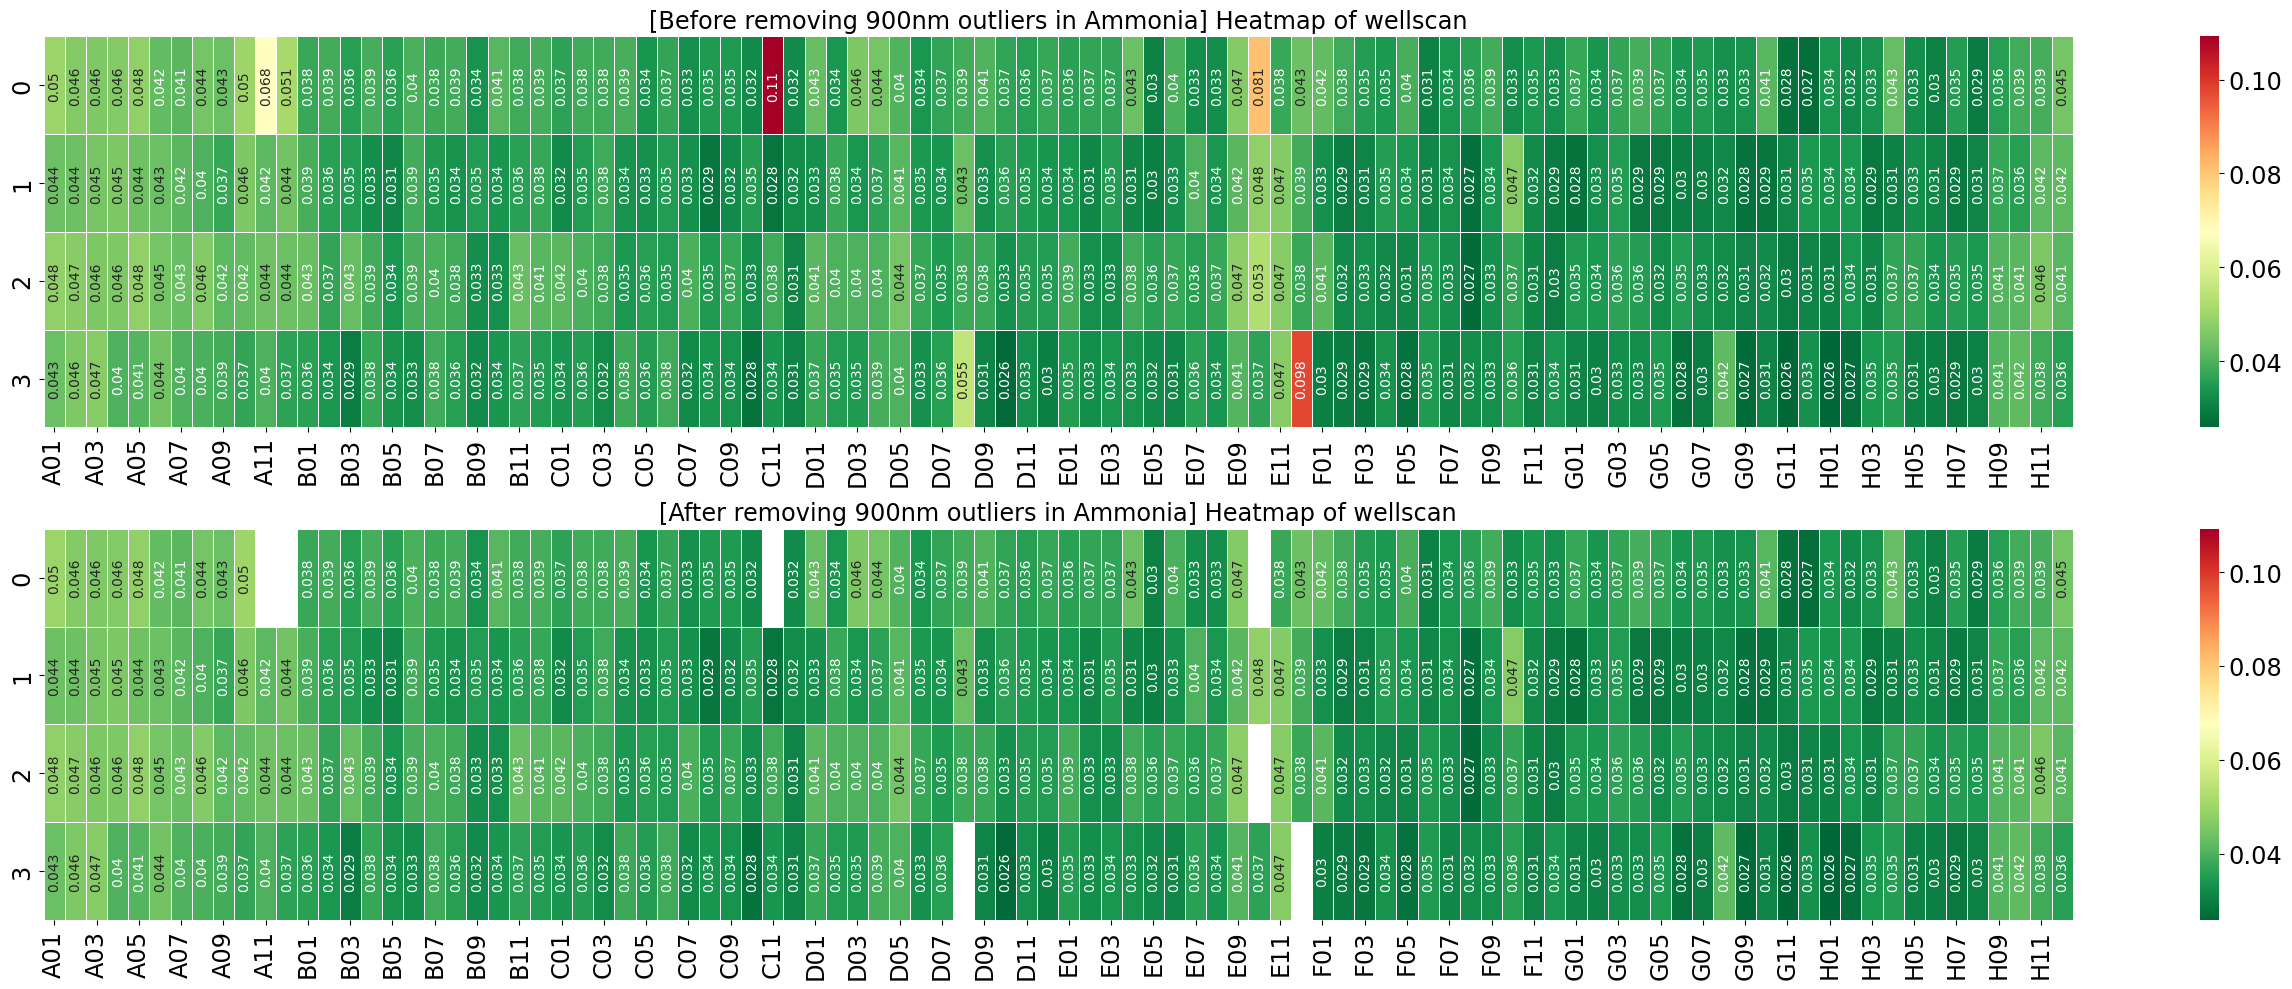

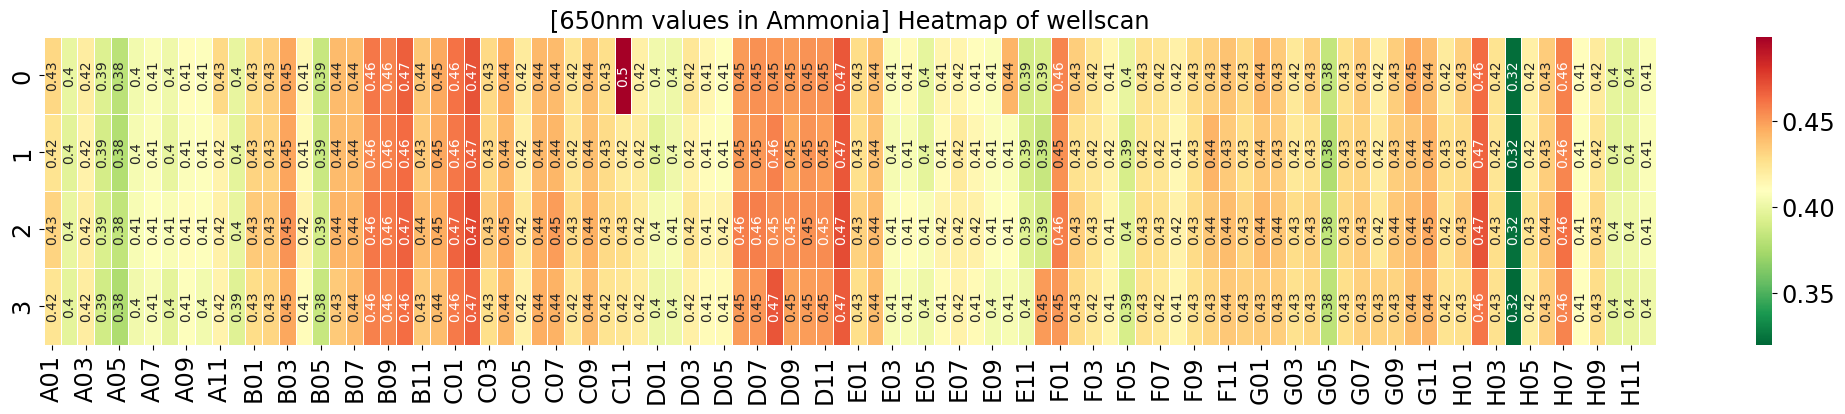

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

returns true for elements more than 1.5 interquartile ranges above the upper quartile


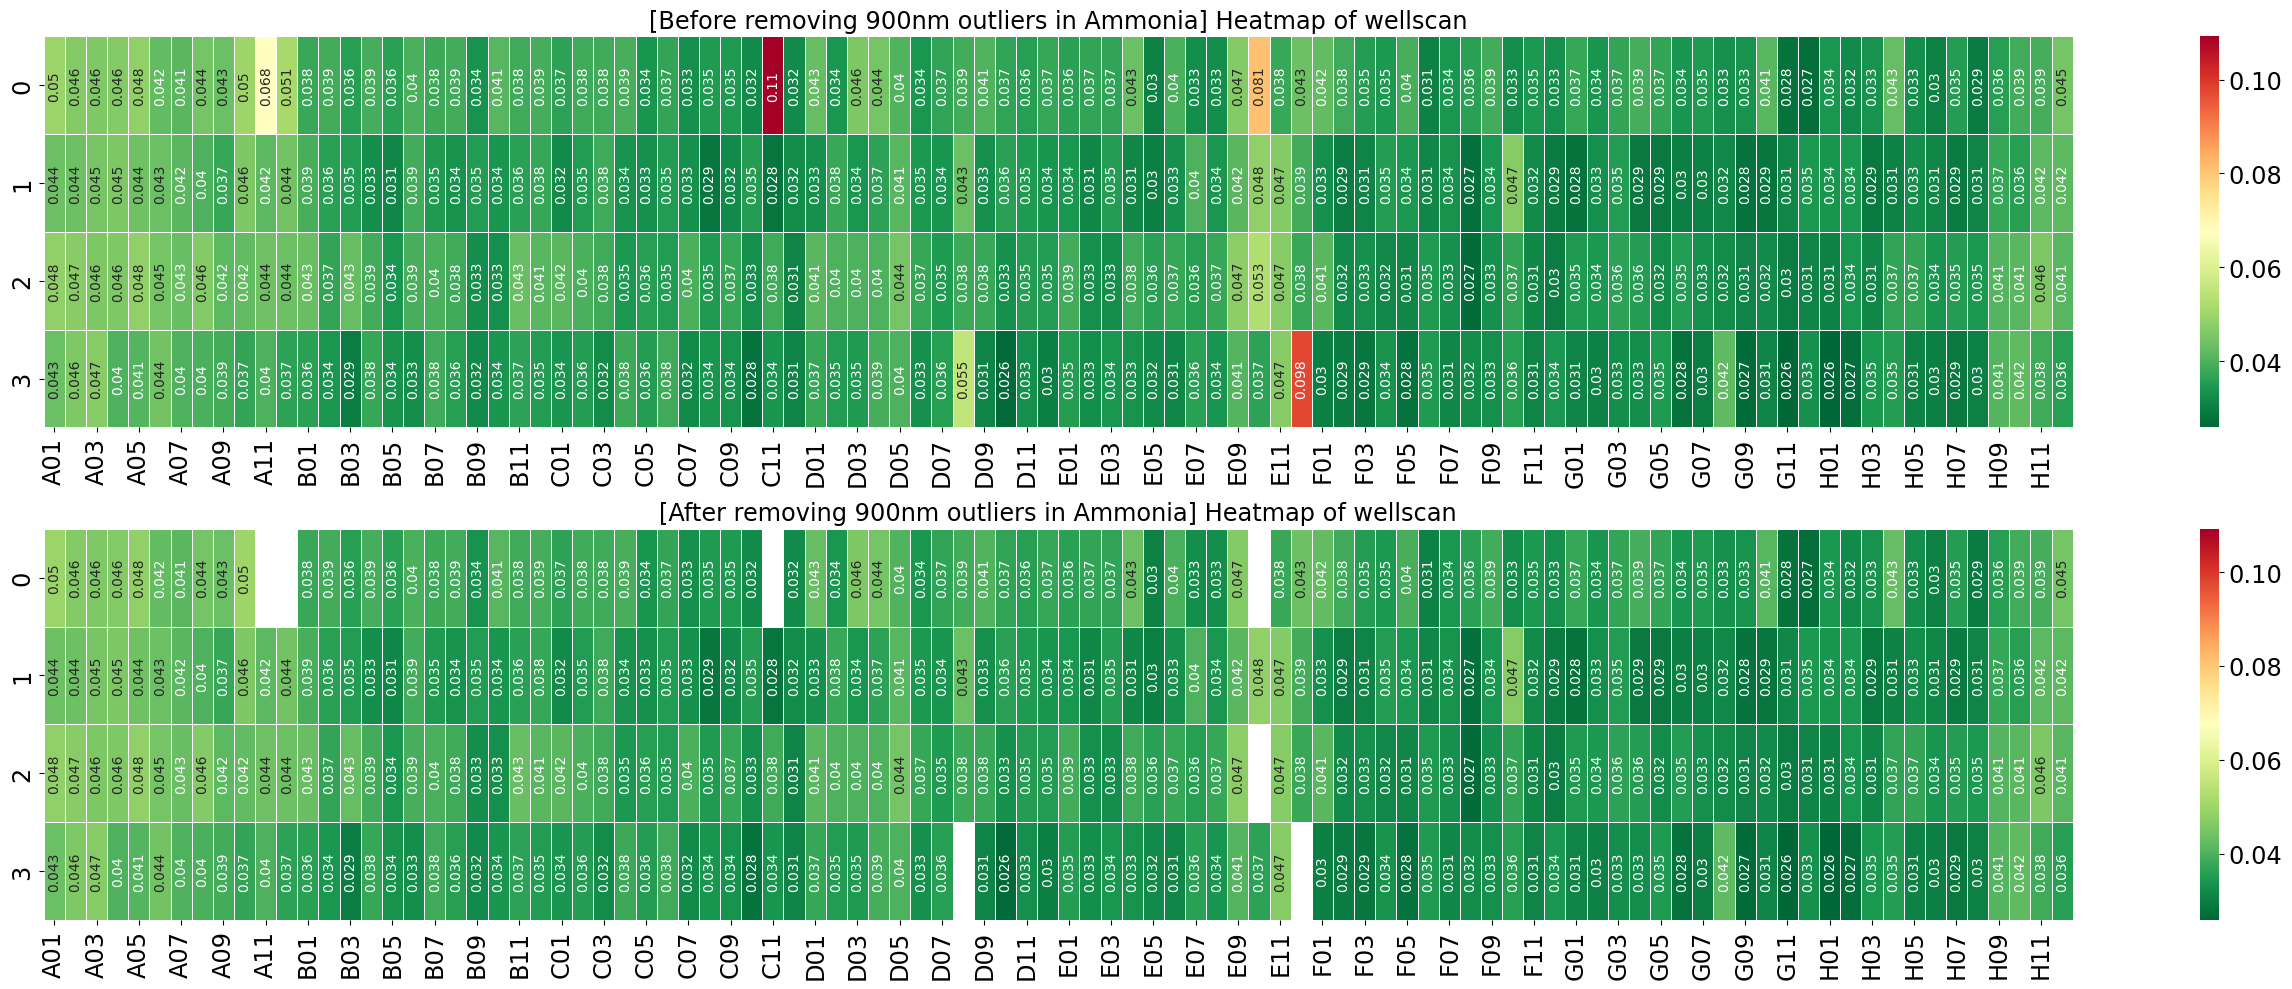

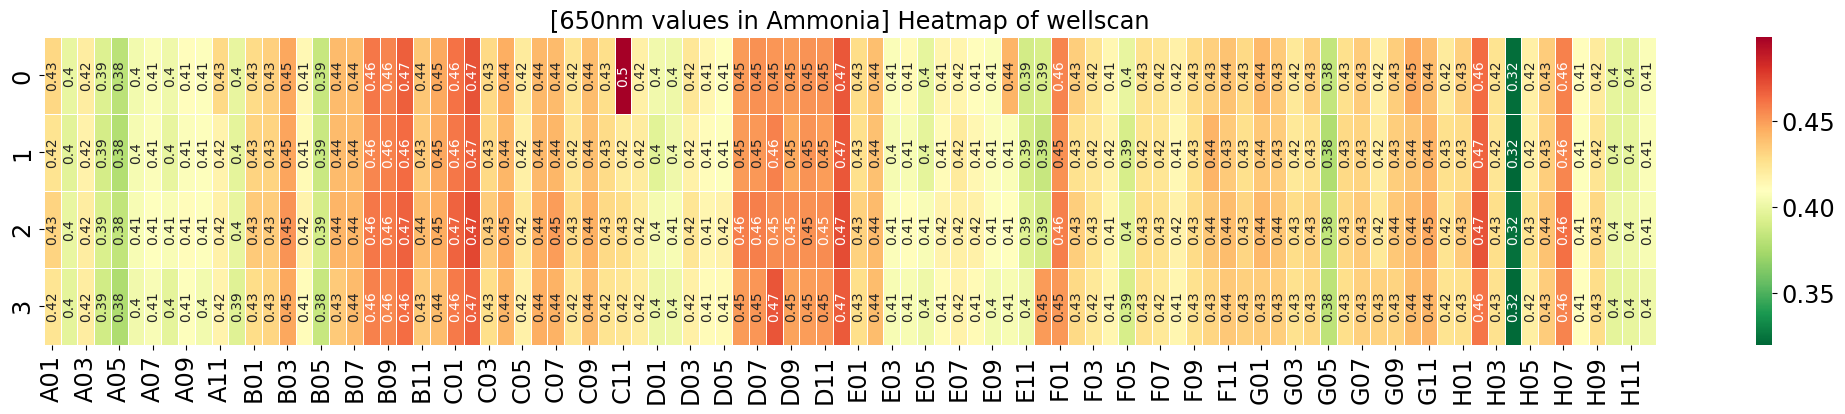

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

returns true for elements more than 1.5 interquartile ranges above the upper quartile


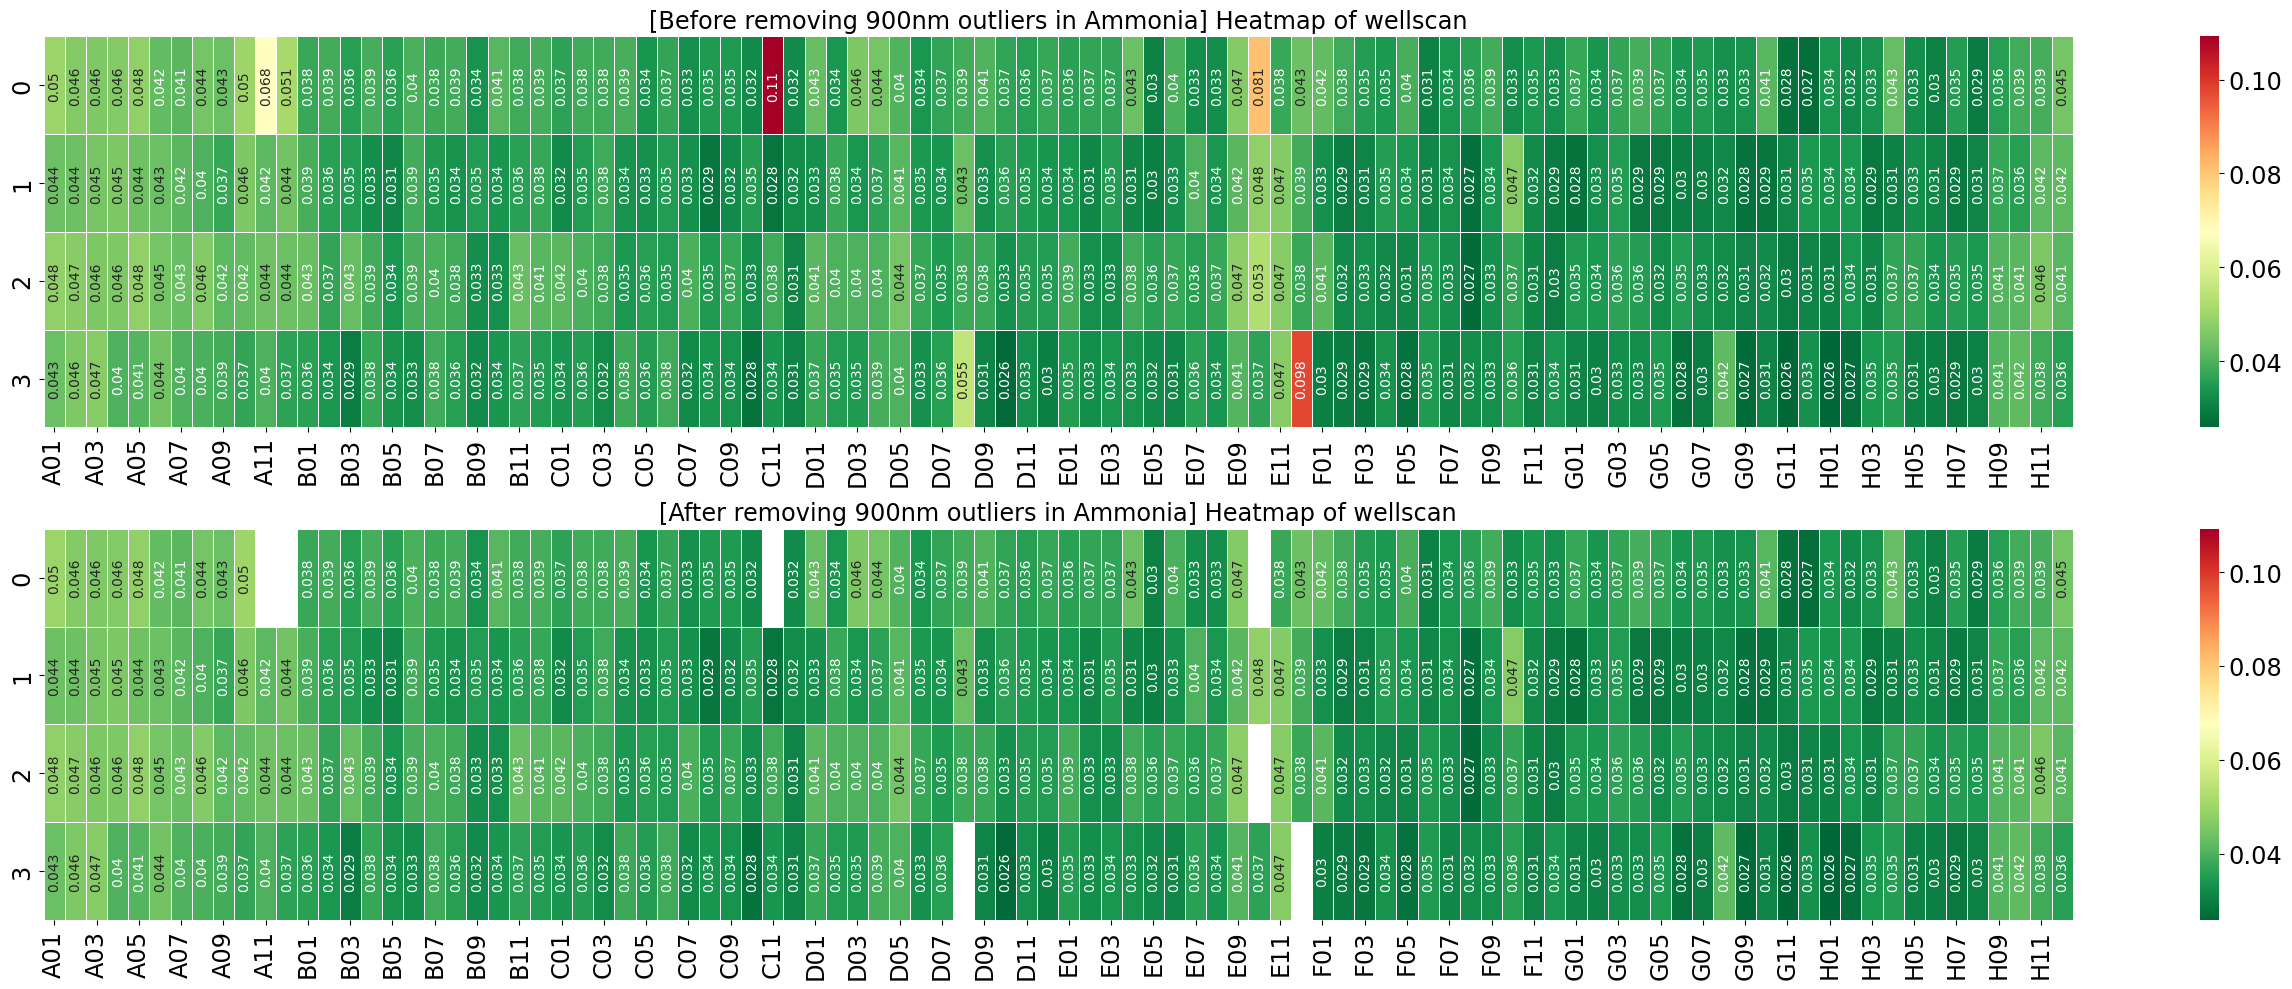

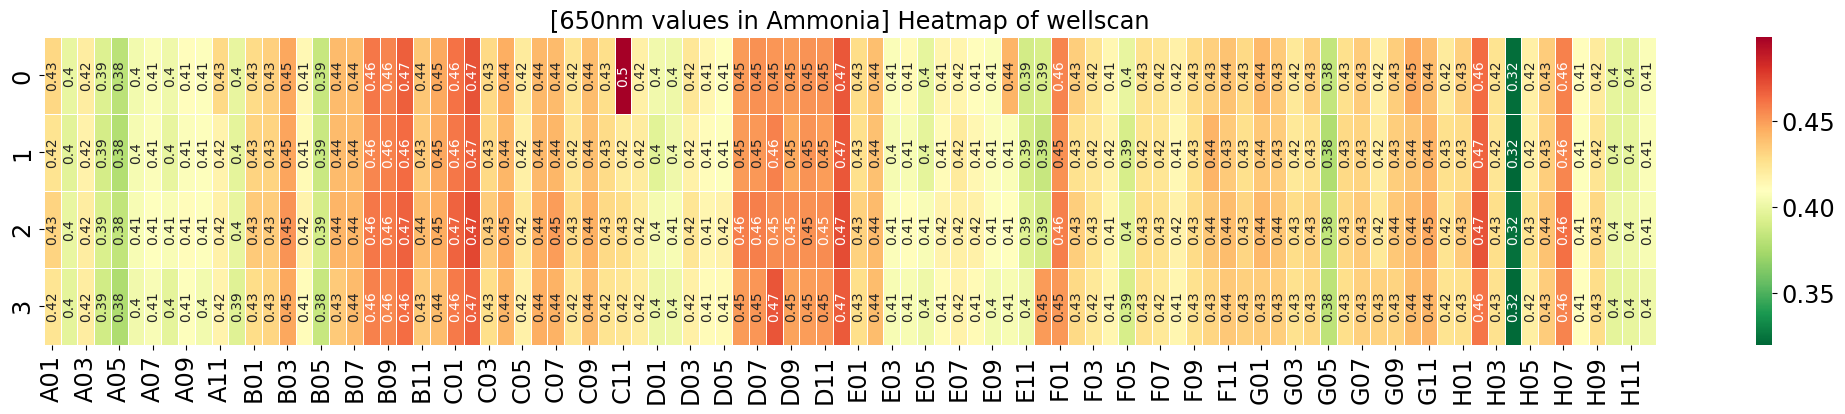

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

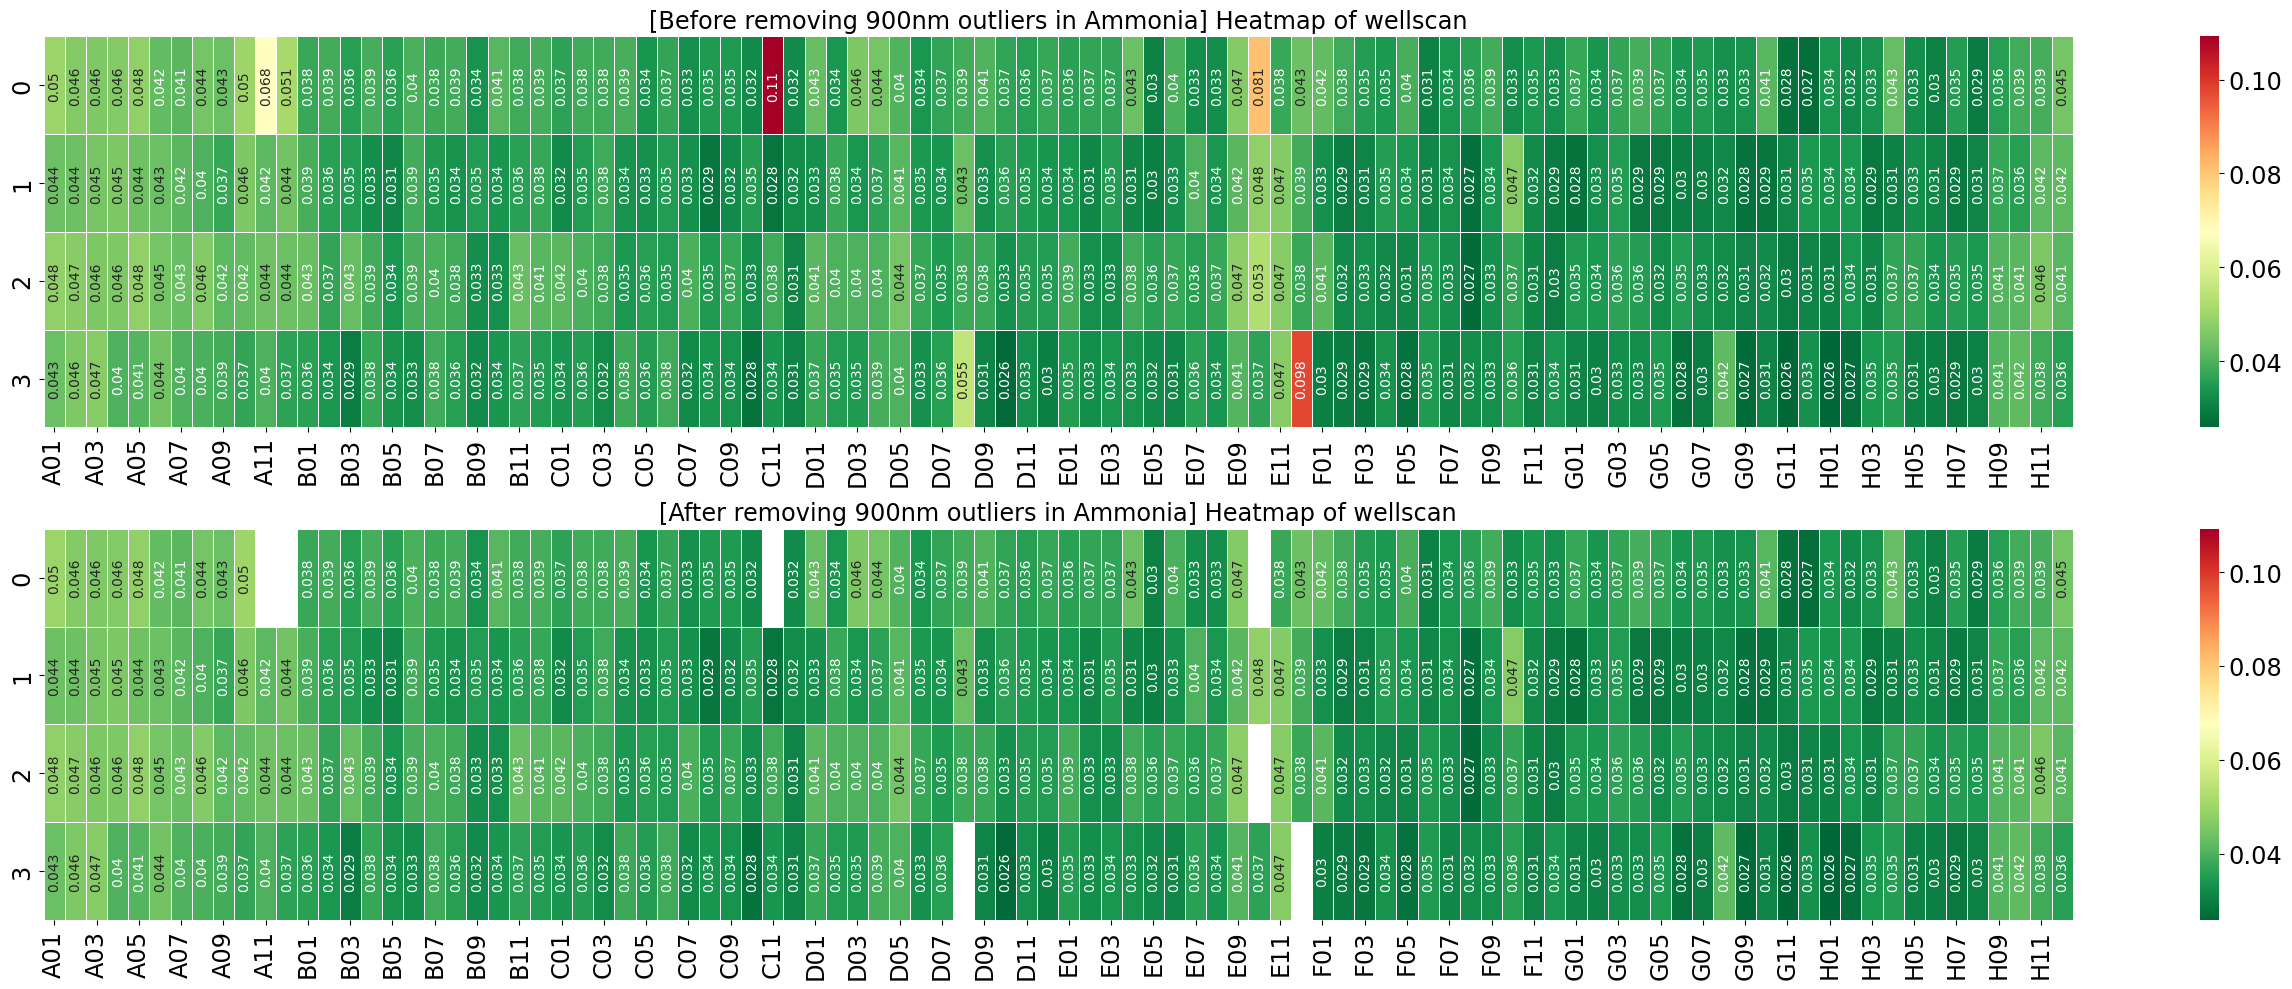

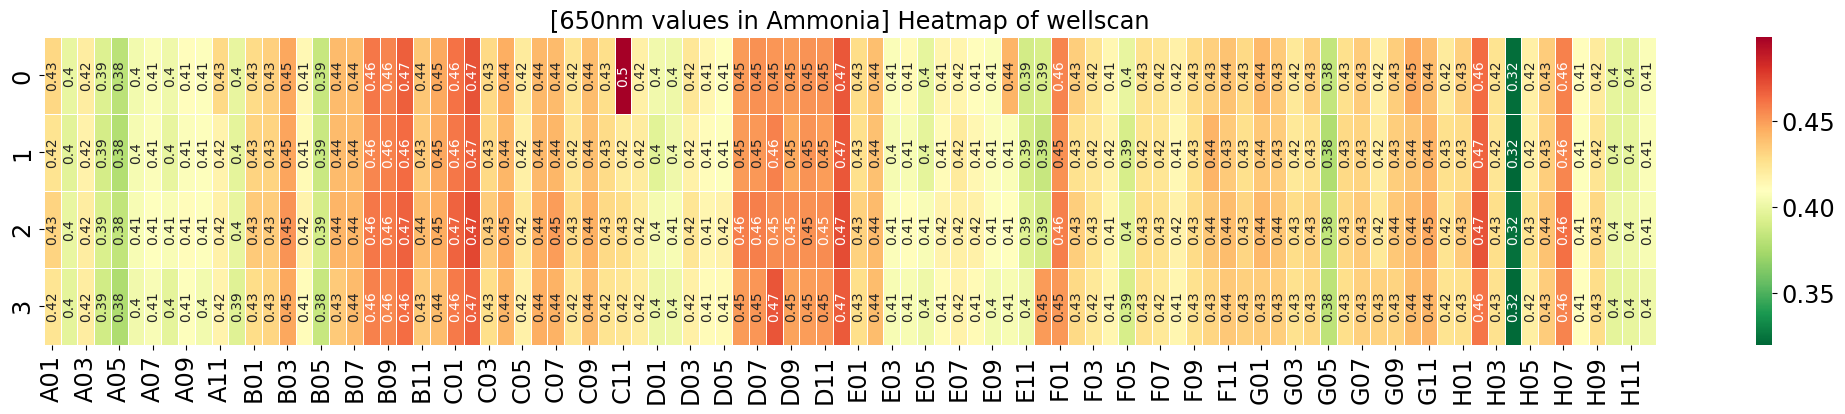

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

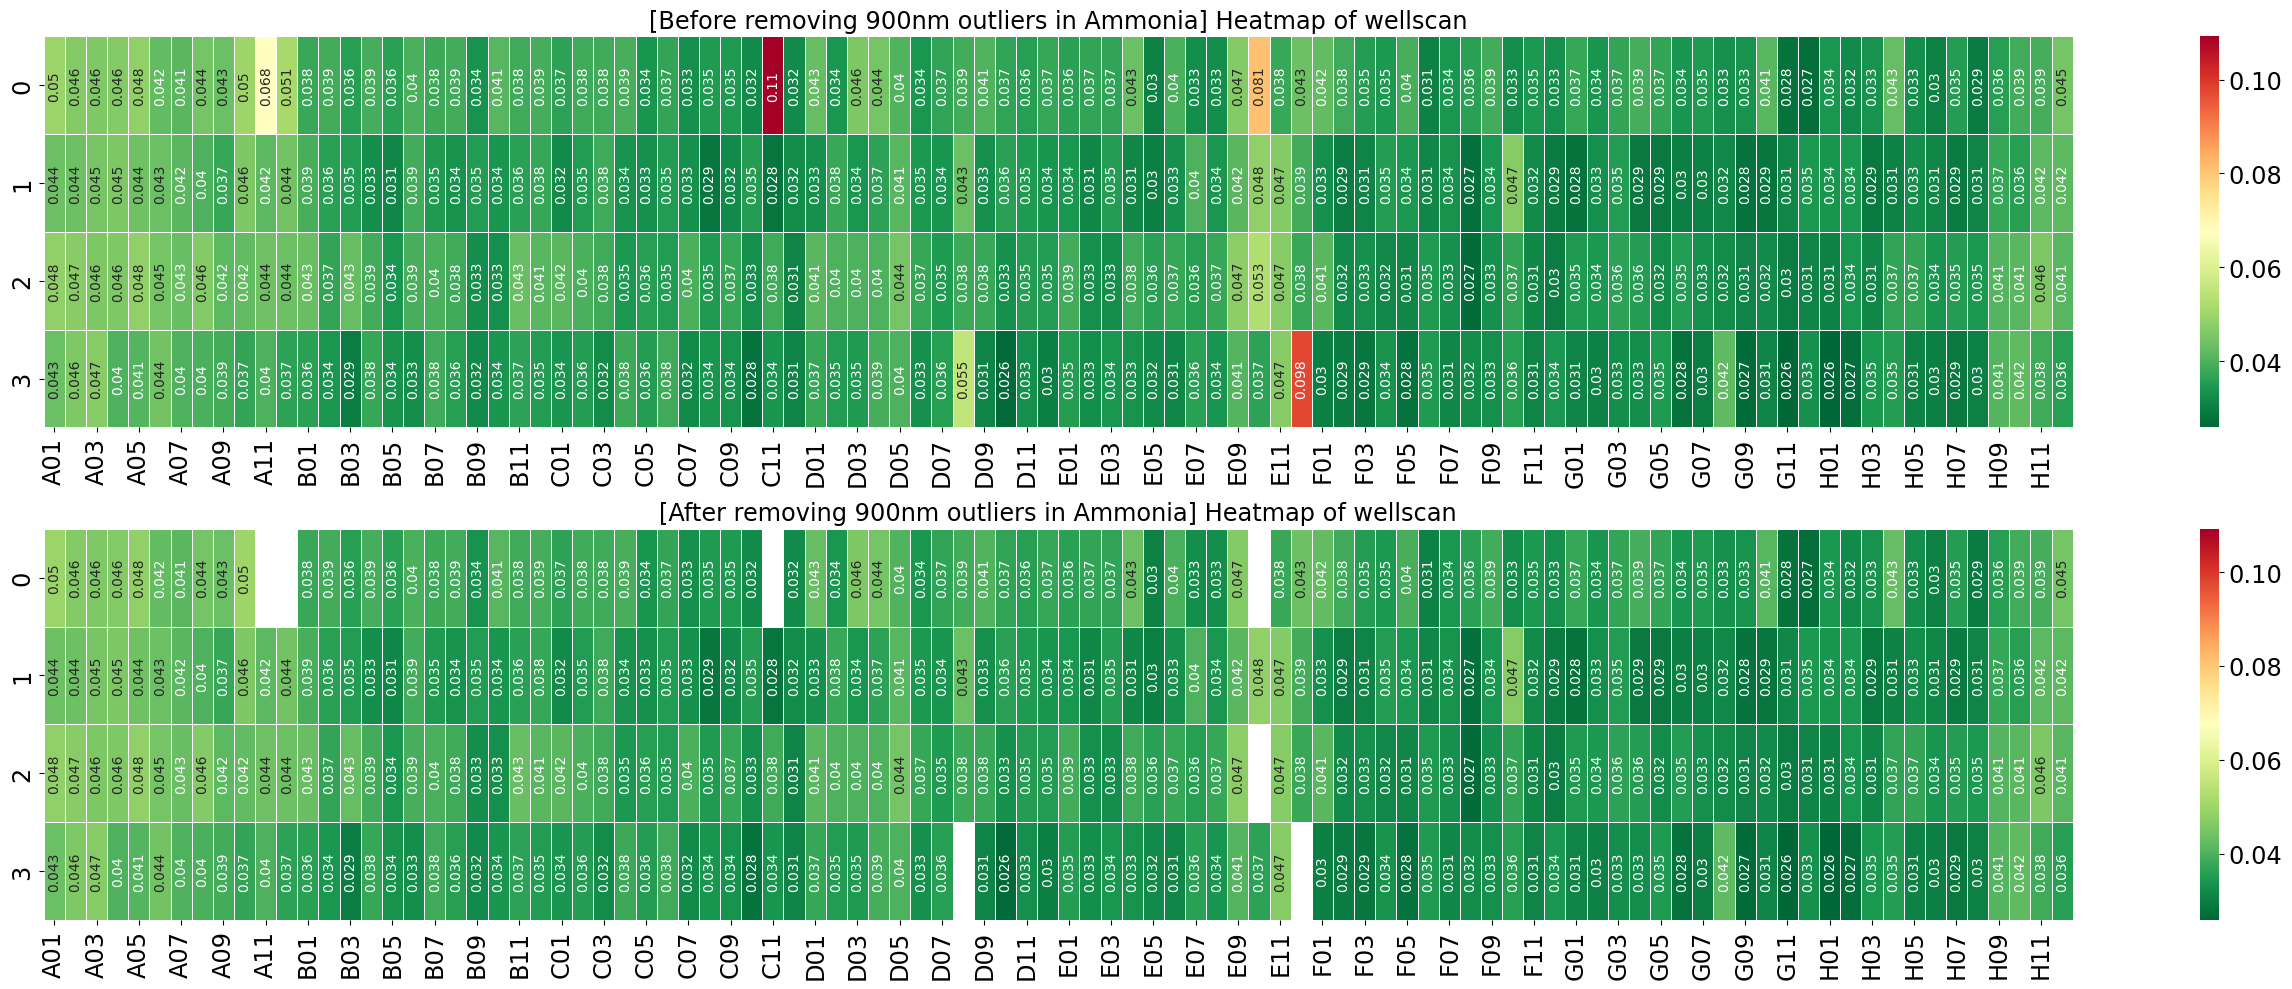

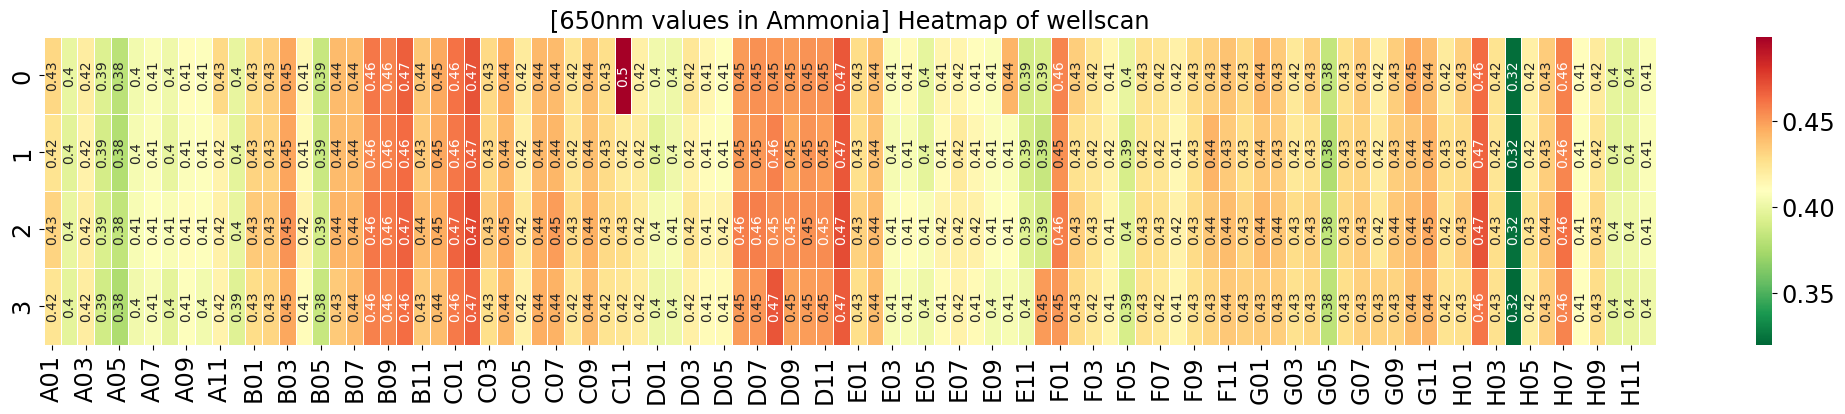

data/20250304_samples_metadata.csv
Currently using this fit:  [0.0037278805246985236, 1.1112302889773742, -0.03978631965983861]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.42445
A02    0.39720
A03    0.41920
A04    0.39100
A05    0.37745
        ...   
H08    0.40960
H09    0.42595
H10    0.39740
H11    0.39785
H12    0.40600
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.228325
A02    0.201075
A03    0.223075
A04    0.194875
A05    0.181325
         ...   
H08    0.213475
H09    0.229825
H10    0.201275
H11    0.201725
H12    0.209875
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.203600
A02    0.178737
A03    0.198806
A04    0.173087
A05    0.160745
         ...   
H08    0.190045
H09    0.204970
H10    0.178919
H11    0.179330
H12    0.186761
Name: Ammonia_mM, Length: 96, dtype: float64
Empty DataFrame
Columns: [Nitrite_input, Nit

/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_absorb.loc[row][bub_900.loc[row]] = np.NaN #Set bubbles to NaN
/Users/ik/codes/cascade/ammonia.py:78: FutureWarning: ChainedAssignmentError: behaviour 

In [ ]:
%pip install openpyxl
# Loop through sample names
for i in l_soil:
    for j in l_timepoint:
        sample_name = i+"_"+j
        print(sample_name)
        plate1_meta_fn = f"data/{date}_samples_metadata.csv"
        print(plate1_meta_fn)
        plate1_am_fn = None
        print(plate1_am_fn)
        plate1_am_absorb_fn = glob.glob(f"data/{date}_NH4_chl*650*")[0]
        print(plate1_am_absorb_fn)
        plate1_am_900_fn = glob.glob(f"data/{date}_NH4_chl*900*")[0]
        print(plate1_am_900_fn)
        
        am.get_concentration_xlsx(excel_output = f"data/{date}_nh4_chl+.xlsx",
                                  ammonia_blank = ammonia_blank, fit = b_fit, meta_fn = plate1_meta_fn, wavelength = "650",
                                  data_fn=plate1_am_fn, data_absorb_fn=plate1_am_absorb_fn, data_900_fn=plate1_am_900_fn)
        
        print("--------------------------------------------------------------------------------------------------------------")

